In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/indian-railway-reservation-tiny-dataset.csv')

In [ ]:
data.head()

,Unnamed: 0,primary_key,Train No,Arrival time,Departure Time,Source Station,Destination Station,Available Seats,dirty_bit
0,0,0,107,00:00:00,10:25:00,SWV,MAO,1000,0
1,1,1,107,11:06:00,11:08:00,SWV,MAO,1000,0
2,2,2,107,11:28:00,11:30:00,SWV,MAO,1000,0
3,3,3,107,12:10:00,00:00:00,SWV,MAO,1000,0
4,4,4,108,00:00:00,20:30:00,MAO,SWV,1000,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           10000 non-null  int64 
 1   primary_key          10000 non-null  int64 
 2   Train No             10000 non-null  int64 
 3   Arrival time         10000 non-null  object
 4   Departure Time       10000 non-null  object
 5   Source Station       10000 non-null  object
 6   Destination Station  10000 non-null  object
 7   Available Seats      10000 non-null  int64 
 8   dirty_bit            10000 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 703.3+ KB


In [ ]:
data.shape

(10000, 9)

In [ ]:
data.isnull().count()

,0
Unnamed: 0,10000
primary_key,10000
Train No,10000
Arrival time,10000
Departure Time,10000
Source Station,10000
Destination Station,10000
Available Seats,10000
dirty_bit,10000


In [ ]:
data.describe()

,Unnamed: 0,primary_key,Train No,Available Seats,dirty_bit
count,10000.00000,10000.000000,10000.000000,10000.0,10000.0
mean,4999.50000,5002.574800,9040.921500,1000.0,0.0
std,2886.89568,2888.127806,3057.040038,0.0,0.0
min,0.00000,0.000000,107.000000,1000.0,0.0
25%,2499.75000,2503.750000,7044.000000,1000.0,0.0
50%,4999.50000,5003.500000,11021.000000,1000.0,0.0
75%,7499.25000,7503.250000,11204.000000,1000.0,0.0
max,9999.00000,10003.000000,12146.000000,1000.0,0.0


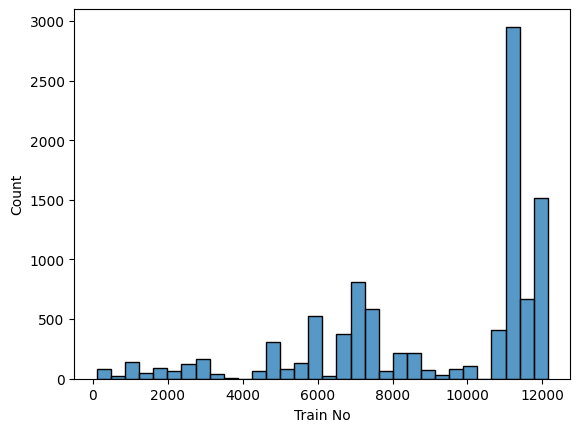

In [ ]:
sns.histplot(data=data, x='Train No')
plt.show()

In [ ]:
data.tail()

,Unnamed: 0,primary_key,Train No,Arrival time,Departure Time,Source Station,Destination Station,Available Seats,dirty_bit
9995,9995,9999,12146,12:30:00,12:55:00,PURI,LTT,1000,0
9996,9996,10000,12146,13:45:00,13:50:00,PURI,LTT,1000,0
9997,9997,10001,12146,15:38:00,15:40:00,PURI,LTT,1000,0
9998,9998,10002,12146,17:50:00,18:00:00,PURI,LTT,1000,0
9999,9999,10003,12146,20:42:00,20:45:00,PURI,LTT,1000,0


In [ ]:
data.columns

Index(['Unnamed: 0', 'primary_key', 'Train No', 'Arrival time',
       'Departure Time', 'Source Station', 'Destination Station',
       'Available Seats', 'dirty_bit'],
      dtype='object')

In [ ]:
data.isnull().sum()

,0
Unnamed: 0,0
primary_key,0
Train No,0
Arrival time,0
Departure Time,0
Source Station,0
Destination Station,0
Available Seats,0
dirty_bit,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.drop_duplicates(inplace=True)

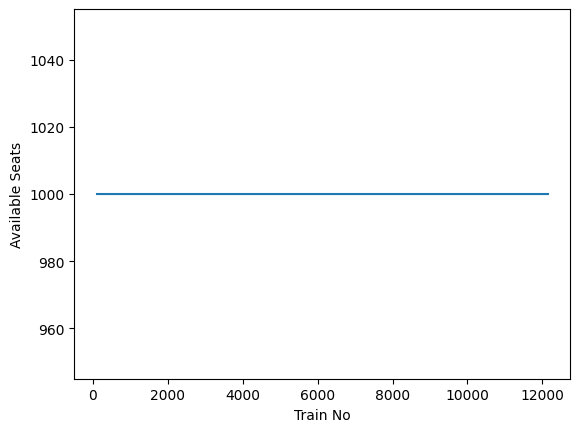

In [ ]:
sns.lineplot(data=data, x="Train No", y="Available Seats")
plt.show()

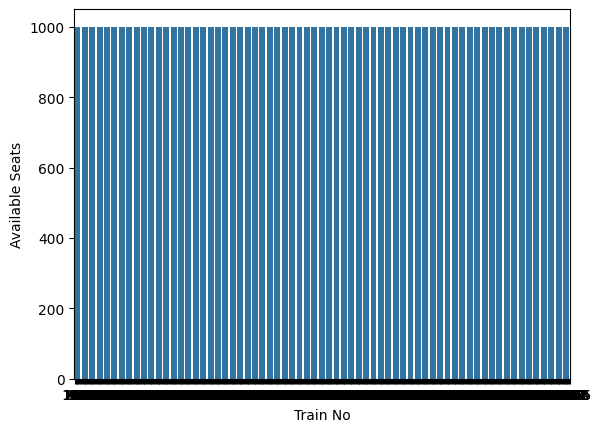

In [ ]:
sns.barplot(data=data, x="Train No", y="Available Seats")
plt.show()

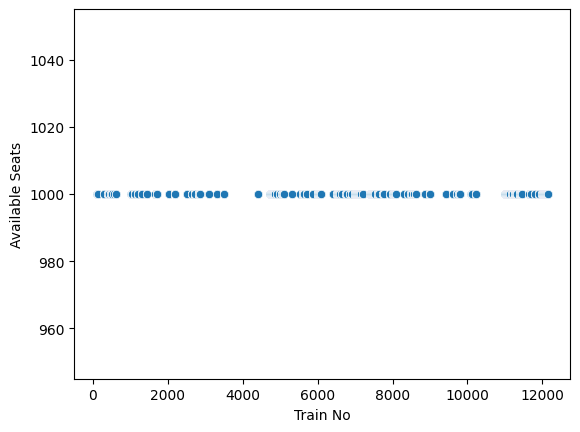

In [ ]:
sns.scatterplot(data=data, x="Train No", y="Available Seats")
plt.show()

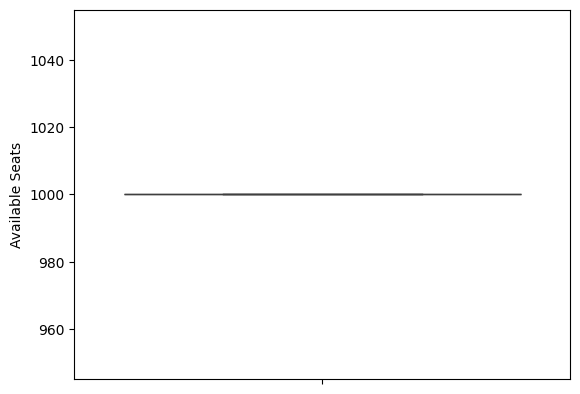

In [ ]:
sns.boxplot(data=data, y="Available Seats")
plt.show()

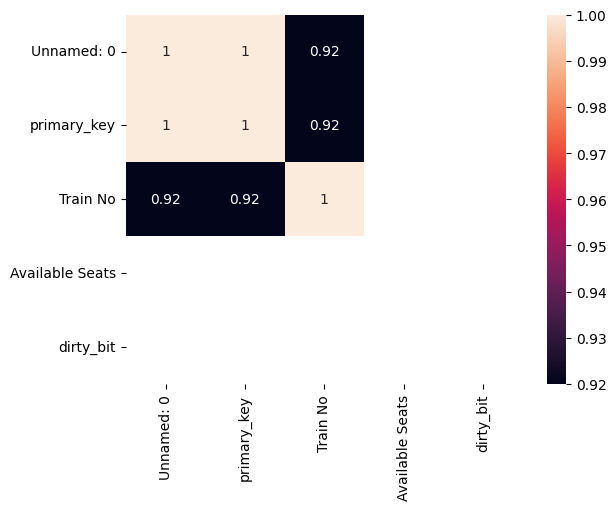

In [ ]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
data_encoded = pd.get_dummies(data, columns=['Source Station', 'Destination Station'], drop_first=True)
print(data_encoded.head())

   Unnamed: 0  primary_key  Train No Arrival time Departure Time  \
0           0            0       107     00:00:00       10:25:00   
1           1            1       107     11:06:00       11:08:00   
2           2            2       107     11:28:00       11:30:00   
3           3            3       107     12:10:00       00:00:00   
4           4            4       108     00:00:00       20:30:00   

   Available Seats  dirty_bit  Source Station_ADB  Source Station_ADI  \
0             1000          0               False               False   
1             1000          0               False               False   
2             1000          0               False               False   
3             1000          0               False               False   
4             1000          0               False               False   

   Source Station_AF  ...  Destination Station_TVC  Destination Station_UBL  \
0              False  ...                    False                    Fal

In [ ]:
data_encoded['Arrival_time_dt'] = pd.to_datetime(data_encoded['Arrival time'], format='%H:%M:%S').dt.time
data_encoded['Departure_time_dt'] = pd.to_datetime(data_encoded['Departure Time'], format='%H:%M:%S').dt.time

# Extract hour and minute as numerical features
data_encoded['Arrival_Hour'] = data_encoded['Arrival_time_dt'].apply(lambda x: x.hour)
data_encoded['Arrival_Minute'] = data_encoded['Arrival_time_dt'].apply(lambda x: x.minute)
data_encoded['Departure_Hour'] = data_encoded['Departure_time_dt'].apply(lambda x: x.hour)
data_encoded['Departure_Minute'] = data_encoded['Departure_time_dt'].apply(lambda x: x.minute)

# Drop original time columns and the intermediate datetime.time columns
data_encoded = data_encoded.drop(columns=['Arrival time', 'Departure Time', 'Arrival_time_dt', 'Departure_time_dt'])

print(data_encoded.head())

   Unnamed: 0  primary_key  Train No  Available Seats  dirty_bit  \
0           0            0       107             1000          0   
1           1            1       107             1000          0   
2           2            2       107             1000          0   
3           3            3       107             1000          0   
4           4            4       108             1000          0   

   Source Station_ADB  Source Station_ADI  Source Station_AF  \
0               False               False              False   
1               False               False              False   
2               False               False              False   
3               False               False              False   
4               False               False              False   

   Source Station_AGC  Source Station_AII  ...  Destination Station_UMB  \
0               False               False  ...                    False   
1               False               False  ...          

In [ ]:
data.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop('Available Seats', axis=1)
y = data_encoded['Available Seats']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)